In [93]:
import warnings
warnings.filterwarnings("ignore")

In [94]:
from tqdm import tqdm
import pandas as pd
from datetime import datetime, timedelta
import sqlite3
import mysql.connector
import pyarrow

import numpy as np

import matplotlib.pyplot as plt

In [95]:
connection = mysql.connector.connect(
    user = 'root',
    password = 'root',
    host = 'localhost',
    port = 3306,
    database = 'Historical_Data'
)
print("MySQL DB Connected")

MySQL DB Connected


In [96]:
cursor = connection.cursor()

cursor.execute("SELECT * FROM FT_DAILY_DATA WHERE Exchange = 'BTC-USD'")

results = cursor.fetchall()

columns = [column[0] for column in cursor.description]


df_original = pd.DataFrame(results, columns=columns)

In [97]:
df_original.sort_values(by = 'id_date', ascending = True)

,Open,High,Low,Close,adj_close,Volume,Exchange,id_exchange,id_date
0,466,468,452,457,457,21056800,BTC-USD,193,20140917
1,457,457,413,424,424,34483200,BTC-USD,193,20140918
2,424,428,385,395,395,37919700,BTC-USD,193,20140919
3,395,423,390,409,409,36863600,BTC-USD,193,20140920
4,408,412,393,399,399,26580100,BTC-USD,193,20140921
...,...,...,...,...,...,...,...,...,...
3527,62901,63092,61124,61553,61553,28186271527,BTC-USD,193,20240514
3528,61554,66454,61330,66267,66267,39815167074,BTC-USD,193,20240515
3529,66256,66712,64613,65232,65232,31573077994,BTC-USD,193,20240516
3530,65231,67459,65119,67052,67052,28031279310,BTC-USD,193,20240517


In [98]:
df = df_original

In [99]:
df['id_date'] = pd.to_datetime(df['id_date'], format='%Y%m%d')
df = df[['Open', 'High', 'Low', 'Close', 'adj_close', 'Volume', 'id_date']]
df

,Open,High,Low,Close,adj_close,Volume,id_date
0,466,468,452,457,457,21056800,2014-09-17
1,457,457,413,424,424,34483200,2014-09-18
2,424,428,385,395,395,37919700,2014-09-19
3,395,423,390,409,409,36863600,2014-09-20
4,408,412,393,399,399,26580100,2014-09-21
...,...,...,...,...,...,...,...
3527,62901,63092,61124,61553,61553,28186271527,2024-05-14
3528,61554,66454,61330,66267,66267,39815167074,2024-05-15
3529,66256,66712,64613,65232,65232,31573077994,2024-05-16
3530,65231,67459,65119,67052,67052,28031279310,2024-05-17


In [100]:
from typing import Tuple

def train_test_split(
    df: pd.DataFrame,
    cutoff_date: datetime,
    target_column_name: str,
    ) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """
    """
    train_data = df[df.id_date < cutoff_date].reset_index(drop=True)
    test_data = df[df.id_date >= cutoff_date].reset_index(drop=True)

    X_train = train_data.drop(columns=[target_column_name])
    y_train = train_data[target_column_name]
    X_test = test_data.drop(columns=[target_column_name])
    y_test = test_data[target_column_name]

    return X_train, y_train, X_test, y_test

In [101]:
from datetime import datetime

X_train, y_train, X_test, y_test = train_test_split(
    df,
    cutoff_date=datetime(2023, 6, 1, 0, 0, 0),
    target_column_name='Close'
)

print(f'{X_train.shape=}')
print(f'{y_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_test.shape=}')

X_train.shape=(3179, 6)
y_train.shape=(3179,)
X_test.shape=(353, 6)
y_test.shape=(353,)


In [102]:
X_train = X_train.apply(lambda col: col.astype(int) if col.name != 'id_date' else col)
X_test = X_test.apply(lambda col: col.astype(int) if col.name != 'id_date' else col)
y_train = y_train.astype(int)
y_test = y_test.astype(int)


X_train_only_numeric = X_train.drop(columns = 'id_date')



X_train_only_numeric.head(5)

,Open,High,Low,adj_close,Volume
0,466,468,452,457,21056800
1,457,457,413,424,34483200
2,424,428,385,395,37919700
3,395,423,390,409,36863600
4,408,412,393,399,26580100


In [103]:
import xgboost as xgb

In [104]:
model = xgb.XGBRegressor()

In [105]:
model.fit(X_train_only_numeric, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [106]:
X_test_only_numeric = X_test.drop(columns = 'id_date')
predictions = model.predict(X_test_only_numeric)
predictions

array([26756.38 , 26922.87 , 27077.484, 27160.502, 26572.96 , 26854.127,
       26674.326, 26728.053, 26728.053, 26495.7  , 26575.912, 26604.746,
       26518.396, 26518.396, 26480.99 , 26439.695, 26728.053, 26568.379,
       26632.408, 28206.393, 29655.68 , 29971.602, 30804.48 , 30809.46 ,
       30778.51 , 30227.518, 30742.172, 30026.701, 30288.742, 31201.955,
       30773.094, 30752.24 , 30807.643, 30778.51 , 30778.51 , 29948.736,
       30322.326, 30295.668, 30295.668, 30232.512, 30809.46 , 30249.188,
       31361.537, 30097.951, 30273.99 , 30273.99 , 30246.258, 29882.018,
       30081.941, 30060.285, 30081.941, 30067.252, 30045.574, 29332.371,
       29242.488, 29278.053, 29270.875, 29299.709, 29285.02 , 29263.342,
       29299.709, 29649.113, 29264.396, 29268.758, 28903.127, 28934.068,
       28959.557, 29267.977, 29881.412, 29865.13 , 29299.709, 29242.488,
       29285.02 , 29285.02 , 29278.053, 29268.758, 28901.309, 26955.941,
       26612.562, 26547.525, 26568.379, 26518.396, 

In [107]:
from sklearn.metrics import mean_absolute_error
test_mae = mean_absolute_error(y_test, predictions)
print(f'{test_mae=:.4f}')

test_mae=722.4245


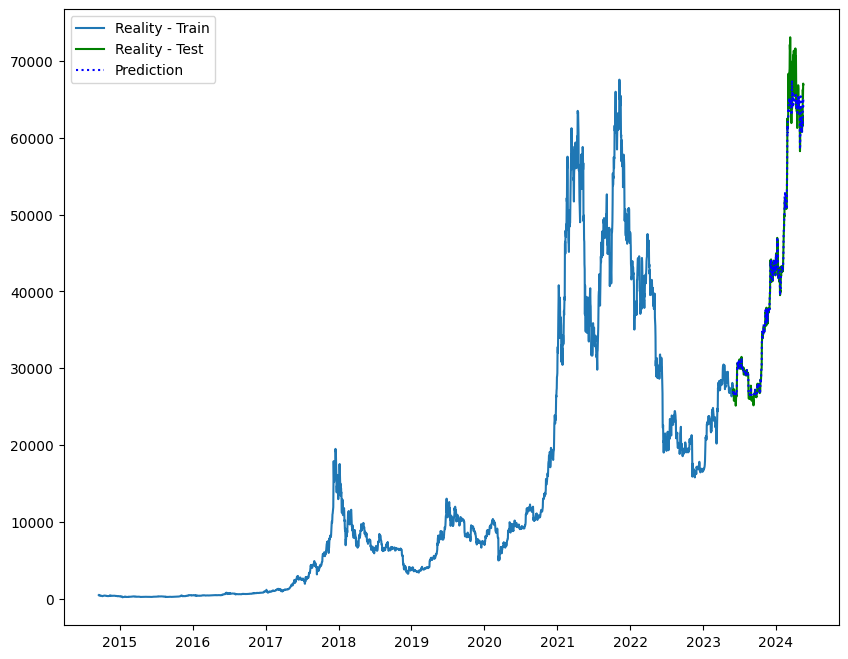

In [108]:
%matplotlib inline
fig = plt.figure(figsize = (10,8))
plt.plot(X_train['id_date'], y_train, label = 'Reality - Train')
plt.plot(X_test['id_date'], y_test, '-g', label = 'Reality - Test')
plt.plot(X_test['id_date'], predictions, ':b', label = 'Prediction')
plt.legend()



#### LIGHTGBM

In [109]:
import lightgbm as lgb

In [110]:
model_lgb = lgb.LGBMRegressor()
model_lgb.fit(X_train_only_numeric, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000215 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 3179, number of used features: 5
[LightGBM] [Info] Start training from score 13439.393835


LGBMRegressor()

In [111]:
X_test_only_numeric = X_test.drop(columns = 'id_date')
predictions = model_lgb.predict(X_test_only_numeric)

from sklearn.metrics import mean_absolute_error
test_mae = mean_absolute_error(y_test, predictions)
print(f'{test_mae=:.4f}')

test_mae=759.3832


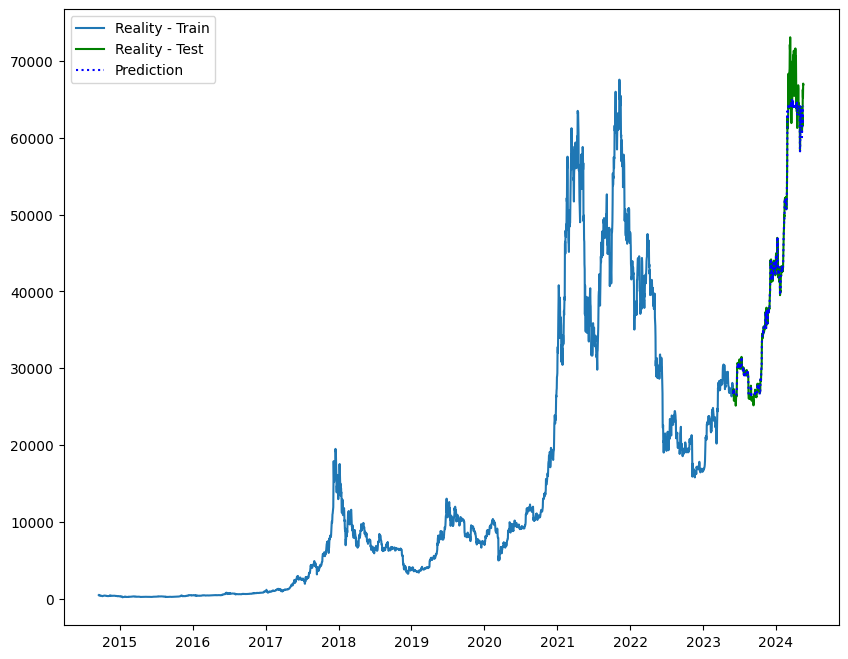

In [112]:
%matplotlib inline
fig = plt.figure(figsize = (10,8))
plt.plot(X_train['id_date'], y_train, label = 'Reality - Train')
plt.plot(X_test['id_date'], y_test, '-g', label = 'Reality - Test')
plt.plot(X_test['id_date'], predictions, ':b', label = 'Prediction')
plt.legend()

